# Part B - Data Preparation

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load Excel file

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (5200, 19)

First 5 Rows:


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [8]:
print("Columns in Dataset:\n")

for col in df.columns:
    print(col)

Columns in Dataset:

student_id
age
country_region
device_type
education_background
course_level
course_category
course_start_date
week_of_year
sessions
time_spent_hours
videos_watched
quiz_attempts
assignments_submitted
forum_posts
avg_quiz_score
attendance_rate
completion_status
final_score


In [9]:
df.columns = df.columns.str.strip()

In [10]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Numerical columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64


In [11]:
label_encoders = {}

for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    label_encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [12]:
print(df.columns.tolist())

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


In [13]:
X_cls = df.drop(columns=['completion_status','final_score'])

y_cls = df['completion_status']

print("Classification Features Shape:", X_cls.shape)
print("Classification Target Shape:", y_cls.shape)

Classification Features Shape: (5200, 17)
Classification Target Shape: (5200,)


In [14]:
X_reg = df.drop(columns=['completion_status','final_score'])

y_reg = df['final_score']

print("Regression Features Shape:", X_reg.shape)
print("Regression Target Shape:", y_reg.shape)

Regression Features Shape: (5200, 17)
Regression Target Shape: (5200,)


In [15]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print("X_train_cls:", X_train_cls.shape)
print("X_test_cls :", X_test_cls.shape)

X_train_cls: (4160, 17)
X_test_cls : (1040, 17)


In [16]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)

X_train_reg: (4160, 17)
X_test_reg : (1040, 17)


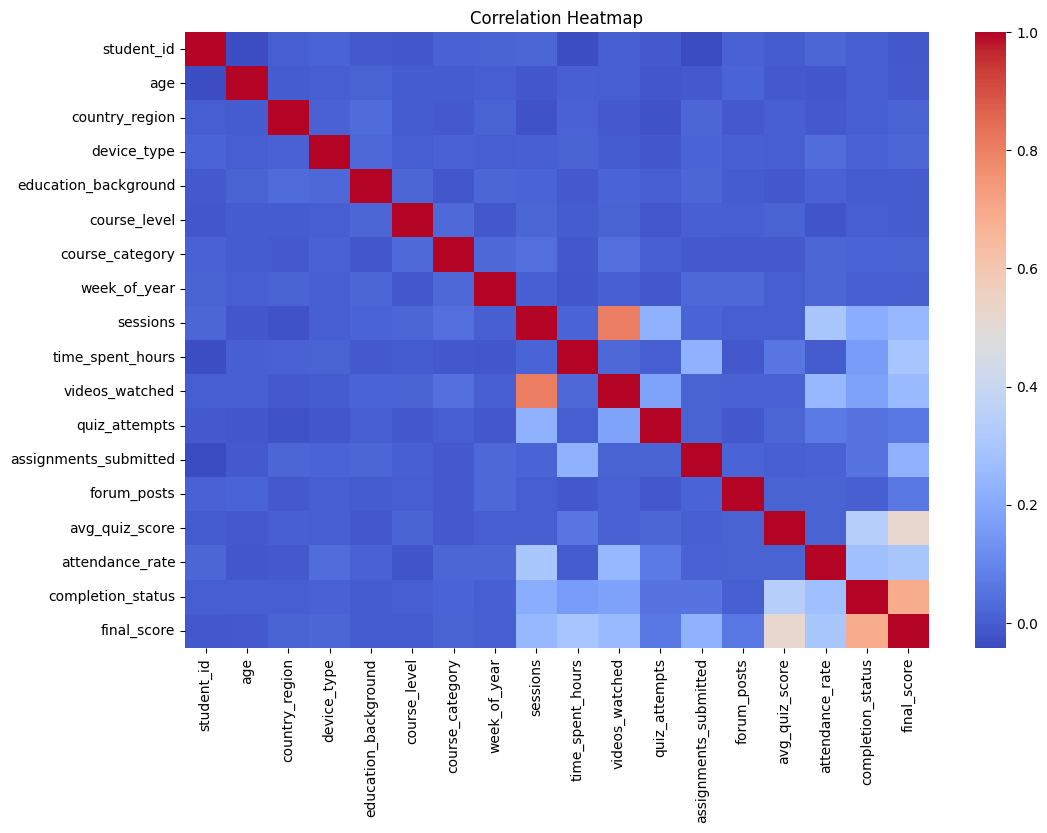

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

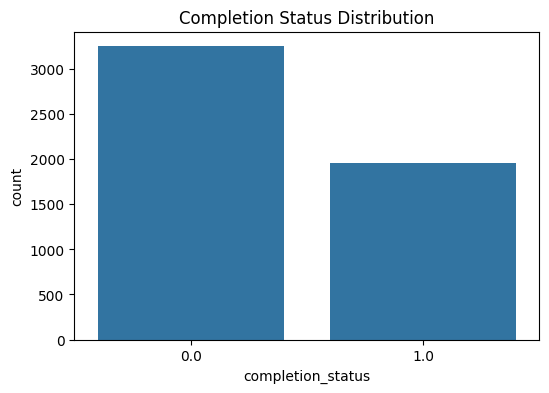

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_cls)

plt.title("Completion Status Distribution")

plt.show()

In [19]:
print("Classification Training Data")

print(X_train_cls.shape)
print(y_train_cls.shape)

print("\nRegression Training Data")

print(X_train_reg.shape)
print(y_train_reg.shape)

Classification Training Data
(4160, 17)
(4160,)

Regression Training Data
(4160, 17)
(4160,)


## Conclusion 

Dataset loaded successfully.

Missing values handled using Median and Most Frequent strategies.

Categorical columns encoded using LabelEncoder.

Data split into Classification and Regression tasks.

Train-Test split completed successfully.

Dataset is now ready for Bagging, Boosting, Voting, and Stacking models in Part C–G.